In [ ]:
"""
Grundbruch case is always Case C (theta<l), Case 2 (student-t)
To be improved, friction angle should not be smaller than beta, need to check

References:
> European Commission (2024) Reliability-based verification of limit states for geotechnical structures. Guidelines for the application of the 2nd generation of Eurocode 7: Geotechnical design.
- Table 12 Case A, B, C
- Figure 19: spatial averaging

- mean: Mean value of the property.
- cov: Coefficient of variation (V_X).
- theta: Scale of fluctuation (spatial variability).
- L: Extent of the zone of influence.
- Case: "1" (V_X known), "2" (V_X unknown), or "3" (V_X assumed).
- X_k: Characteristic value.

"""

import numpy as np
from math import radians, degrees, sin, cos, tan, sqrt, asin, atan, exp, pi
from scipy.stats import t
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -----------------------
# INPUTS (Retaining Wall)
# -----------------------
n = 30            # Number of samples
L_wall = 3.5      # Total foundation width (b' in DIN 4017 L calculation)
B = L_wall / 1.25 # Width of the vertical component
H = 8       # Height of wall
beta = 5            # Backfill inclination angle
gamma_wall = 23.6   # Unit weight of wall
gamma1 = 20         # Unit weight of backfill
gamma2 = 17         # Unit weight of underground (for bearing capacity)
m = 2               # Load inclination exponent (Eurocode/DIN)

# Soil Parameters - Backfill (phi1)
phi1_mean = 30
phi1_cov = 0.1
phi1_theta = 5

# Soil Parameters - Underground soil (phi2) - Governs Bearing Capacity L
phi2_mean = 30
phi2_cov = 0.1
phi2_theta = 5 

# Soil Parameters - Backfill (Cohesion)
c1_mean = 20
c1_cov = 0.4
c1_theta = 5

# Soil Parameters - Underground soil(Cohesion)
c2_mean = 20
c2_cov = 0.4
c2_theta = 5

Case = "2"          # Case "2" for Student-t distribution
alpha_4017 = 0      # Wall inclination angle for DIN 4017 
beta_4017 = 0       # Backfill angle for DIN 4017 

# Partial Factors
gamma_Rv = 1.4  # GEO-2 Bodenwiderstände - Erdwiderstand und Grundbruchwiderstand
gamma_N = 1.35  # GEO-2 Beanspruchungen aus ständige Einwirkungen allgemein

# Utility Functions
def _clip_sin_arg(x: float) -> float:
    return max(-1.0, min(1.0, x))

def _nz(x: float, eps: float = 1e-12) -> float:
    return x if abs(x) > eps else (eps if x >= 0.0 else -eps)

# ----------------------------------------------------------
# A. Retaining Wall Limit State Function (get_limit_state_G)
# ----------------------------------------------------------
def compute_delta_action_and_geometry(
        B, L_wall, H, beta,
        gamma_wall, gamma1,
        phi1_k, c1_k
    ):
    """
    Computes all earth-pressure related terms:
      delta_action_deg, tan_delta_action,
      T_k, N_k,
      e, L_prime,
      lever arms, G1, G2.
    """

    alpha = degrees(atan((L_wall - B) / H))

    # 1. Wall weights
    G1 = gamma_wall * B * H
    G2 = gamma_wall * (L_wall - B) * H / 2

    # 2. Interface friction from backfill
    delta1 = (2/3) * phi1_k

    # 3. Earth pressure coefficients
    num = cos(radians(phi1_k - alpha))
    den1 = cos(radians(alpha))

    sin_part = sin(radians(phi1_k + delta1)) * sin(radians(phi1_k - beta))
    cos_part = cos(radians(alpha - beta)) * cos(radians(alpha + delta1))

    ratio = sin_part / cos_part if abs(cos_part) > 1e-12 else 0.0
    den2 = sqrt(max(1e-12, ratio))

    K_agh = (num / (den1 * (1 + den2))) ** 2

    K_ach = (2 * cos(radians(alpha - beta)) * cos(radians(phi1_k))
             * cos(radians(alpha + delta1))) / \
            (1 + sin(radians(phi1_k + delta1 + alpha - beta))
             * cos(radians(alpha)))

    # 4. Earth pressure
    e_ach = -c1_k * K_ach
    e_agh = gamma1 * H * K_agh
    e_ah = e_agh + e_ach

    z_start = max(0.0, min(H, (c1_k*K_ach)/(K_agh*gamma1)))
    H_new = max(0.0, H - z_start)

    E_ah = 0.5 * max(0.0, e_ah) * H_new
    xM_Eagh = H_new/3 if H_new > 0 else H/3

    # Mindesterdruck
    phi_min = 40.0
    delta_min = (2/3)*phi_min

    num_min = cos(radians(phi_min - alpha))
    den1_min = cos(radians(alpha))
    sin_min = sin(radians(phi_min + delta_min))*sin(radians(phi_min - beta))
    cos_min = cos(radians(alpha - beta))*cos(radians(alpha + delta_min))

    ratio_min = sin_min / cos_min if abs(cos_min)>1e-12 else 0
    den2_min = sqrt(max(1e-12, ratio_min))
    K_agh_min = (num_min/(den1_min*(1+den2_min)))**2

    E_ah_min = 0.5 * gamma1 * H**2 * K_agh_min

    if E_ah > E_ah_min:
        T_k = E_ah
        ratio_v = 1 - xM_Eagh/H
        xM_Eagv = B + ratio_v*(L_wall - B) - L_wall/2
    else:
        T_k = E_ah_min
        xM_Eagh = H/3
        xM_Eagv = B + (2/3)*(L_wall-B) - L_wall/2

    # 5. Vertical component
    E_av = T_k * tan(radians(delta1))
    N_k = E_av + G1 + G2

    # 6. delta action
    tan_delta_action = T_k / max(N_k, 1e-12)
    delta_action_deg = degrees(atan(tan_delta_action))

    # 7. Moment equilibrium
    xM_G1 = L_wall/2 - B/2
    xM_G2 = L_wall/2 - (2/3)*(L_wall-B)

    sum_M = (
        G1*xM_G1
        + G2*xM_G2
        + (T_k * tan(radians((2/3)*phi1_k))) * xM_Eagv
        - T_k * xM_Eagh
    )

    # 8. Eccentricity and L'
    e = sum_M / max(N_k, 1e-12)
    L_prime = max(1e-3, L_wall - 2*abs(e))

    return {
        "delta_action_deg": delta_action_deg,
        "tan_delta_action": tan_delta_action,
        "N_k": N_k,
        "T_k": T_k,
        "e": e,
        "L_prime": L_prime,
        "G1": G1,
        "G2": G2
    }

def compute_G(N_k, L_prime, tan_delta_action,
              gamma2, phi2_k, c2_k,
              gamma_Rv, gamma_N, m):
    """
    Compute bearing-capacity limit state G.

    Uses:
      - φ2_k, c2_k (subsoil)
      - tan_delta_action (from T_k/N_k)
      - L_prime, N_k from function 1
    """

    one_minus_tan = max(0.0, 1.0 - tan_delta_action)

    # Bearing capacity factors
    Nd0 = (tan(radians(45)+radians(phi2_k)/2)**2) * exp(pi*tan(radians(phi2_k)))
    Nb0 = (Nd0 - 1) * tan(radians(phi2_k))
    Nc0 = (Nd0 - 1) / max(tan(radians(phi2_k)), 1e-12)

    # Load inclination factors
    ib = one_minus_tan**(m+1)
    id = one_minus_tan**m
    ic = (id*Nd0 - 1) / max(Nd0 - 1, 1e-12)

    Nb = Nb0 * ib
    Nc = Nc0 * ic

    # Ultimate bearing capacity
    R_k = L_prime * (gamma2 * L_prime * Nb + c2_k * Nc)

    # Design
    R_d = R_k / gamma_Rv
    N_d = N_k * gamma_N

    G = R_d - N_d

    return {
        "G": G
    }

# ----------------------------------------------------------
# B. Backfill Characteristic Length
# ----------------------------------------------------------
def characteristic_length_backfill(H, B, L_wall, phi_deg, beta_deg, delta_a_deg):
    """
    Computes:
      1) Active sliding-plane angle θ_ag (DIN 4085)
      2) Length of the failure plane s 

    All angles are input in degrees.
    Returns:
      s_failure    : float
    """

    # -------- Convert to radians --------
    phi    = radians(phi_deg)
    alpha  = atan((L_wall - B) / H)
    beta   = radians(beta_deg)
    delta  = radians(delta_a_deg)

    # ----------------------------------------------
    # 1. θ_ag according to DIN 4085 (active case)
    # ----------------------------------------------
    from math import sin, cos, sqrt, atan2

    # all angles must be in RADIANS
    # phi, alpha, beta, delta_a

    frac = (sin(phi + delta) * cos(alpha - beta)) / (sin(phi - beta) * cos(alpha + delta))
    inner = sin(phi - alpha) + sqrt(frac)

    # atan2(y, x) = atan(y/x) but safer
    theta_ag = phi + atan2(cos(phi - alpha), inner)

    theta_ag_deg = degrees(theta_ag)

    # ----------------------------------------------
    # 2. Failure-plane length s 
    #     s = [H cos β + (L_wall - B) sin β] / sin(θ_ag − β)
    # ----------------------------------------------
    num = H * cos(beta) + (L_wall - B) * sin(beta)
    denom = sin(theta_ag - beta)

    if denom <= 0 or num <= 0:
        s_failure = float("inf")
    else:
        s_failure = num / denom

    return s_failure
# ----------------------------------------------------------
# C. Underground Characteristic Length
# ----------------------------------------------------------
def characteristic_length_underground (alpha, beta, phi, delta, b):
    # Use DIN 4017-7.2 for characteristic length of base failure wedge
    phi = float(phi) 
    sin_epsilon1 = _clip_sin_arg(-sin(radians(beta)) / _nz(sin(radians(phi))))
    epsilon1 = degrees(asin(sin_epsilon1))

    sin_epsilon2 = _clip_sin_arg(-sin(radians(delta)) / _nz(sin(radians(phi))))
    epsilon2 = degrees(asin(sin_epsilon2))

    theta1 = 45.0 - phi/2.0 - (epsilon1 + beta)/2.0
    theta2 = 45.0 + phi/2.0 - (epsilon2 - delta)/2.0
    theta3 = 45.0 + phi/2.0 + (epsilon2 - delta)/2.0
    nu = 180.0 - alpha - beta - theta1 - theta2

    denom = cos(radians(alpha)) * _nz(sin(radians(theta3 + theta2)))
    r2 = b * sin(radians(theta3)) / _nz(denom)

    r1 = r2 * exp((pi / 180.0) * nu * tan(radians(phi)))
    l = r1 * cos(radians(phi)) / _nz(cos(radians(theta1 + phi)))

    z_a = r2 * sin (radians(theta2))
    l1 = z_a / _nz(sin(radians(theta3)))

    l2 = sqrt(max(0.0, r1**2 + l**2 - 2 * r1 * l * _clip_sin_arg(cos(radians(theta1)))))

    ls= (r1-r2)/_nz(sin(radians(phi)))

    l_sum = l1 + l2 + ls  
    return float(l_sum)

# ----------------------------------------------------------
# C. Characteristic Value Calculation 
# ----------------------------------------------------------
def _kn_from_gamma_sq(gamma_sq: float, Case: str, n: int) -> float:
    gamma_sq = float(np.clip(gamma_sq, 0.0, 1.0))
    N95 = 1.645
    t95 = t.ppf(0.95, n - 1)
    if Case in ("1", "3"):    # normal
        return N95 * sqrt(gamma_sq + 1.0 / n)
    else:                     # "2": Student-t
        return t95 * sqrt(gamma_sq + 1.0 / n)

def _char_value_with_gamma_sq(mean: float, cov: float, gamma_sq: float, Case: str, n: int) -> float:  #characteristic value
    k_n = _kn_from_gamma_sq(gamma_sq, Case, n)
    return mean * (1.0 - k_n * cov)

def _implied_gamma_sq_from_length(theta_corr: float, L: float) -> float:  # calculate gamma square
    if not np.isfinite(L) or L <= 0.0:  # if L is not a real number, no averaging
        return 1.0
    return float(min(1.0, max(0.0, theta_corr / L))) # so it would not exceed 1, and not negative

# ----------------------------------------------------------
# D. Iterative Solver (Fixed-Point)
# ----------------------------------------------------------
def solve_gamma_phi_fixed_point_wall_earth_pressure(
    *, L_wall, B, H, beta, gamma_wall, gamma1, 
    phi1_mean, phi1_cov, phi1_theta,
    c1_mean, c1_cov, c1_theta,
    Case, n,
    tol: float = 1e-4, itmax: int = 80,
    g_init: float | None = None
) -> dict:
    """
    Solve ONLY the characteristic-length consistency: (g2 is gamma square)
      g2 = min(1, theta / L(phi_k(g2), delta(g2)))
    via bisection on g2 in [0,1] if bracketed; else relaxed fixed-point.
    Returns gamma_sq, phi_k, L, delta, diagnostics (incl. G), and metadata.    
    """
    def eval_at(g2: float) -> dict:
        # Calculate characteristic values based on g2
        phi1_k = _char_value_with_gamma_sq(phi1_mean, phi1_cov, g2, Case, n)
        c1_k = c1_mean if c1_cov == 0 else _char_value_with_gamma_sq(
                                                c1_mean, c1_cov, g2, Case, n)

        # 1. Calculate loads and action inclination (delta) using characteristic values
        r = compute_delta_action_and_geometry(B, L_wall, H, beta,gamma_wall, gamma1,phi1_k, c1_k)
    
        delta_action_deg = float(r["delta_action_deg"])
        tan_delta = float(r["tan_delta_action"])  # Get action angle
        N_k     = float(r["N_k"])
        T_k     = float(r["T_k"])
        e       = float(r["e"])
        G1      = float(r["G1"])
        G2      = float(r["G2"])
        L_prime = float(r["L_prime"]) 

        # 2. Calculate the characteristic length (L) of the failure wedge
        S = characteristic_length_backfill(H, B, L_wall, phi1_k, beta, delta_action_deg)
        
        # 3. Determine the implied g2_real
        g2_real = _implied_gamma_sq_from_length(phi1_theta, S)
        #g2_c1_real   = _implied_gamma_sq_from_length(c1_theta,  S)


        return {
            "res": g2 - g2_real,
            "g2_real": g2_real,
            "phi1_k": phi1_k,
            "c1_k": c1_k,
            "tan_delta_action":float(r["tan_delta_action"]),
            "delta_action_deg":float(r["delta_action_deg"]),
            "N_k" :float(r["N_k"]),
            "L_prime" : float(r["L_prime"]),
            "delta_deg": float(r["delta_action_deg"]),
            "S": S,
            "diagnostics": r
        }
    
    lo, hi = 0.0, 1.0
    e_lo, e_hi = eval_at(lo), eval_at(hi)

    # --- Try bisection if we have a bracket over [0,1]
    if np.isfinite(e_lo["res"]) and np.isfinite(e_hi["res"]) and e_lo["res"] * e_hi["res"] <= 0.0:
        a_g, b_g = lo, hi
        a_e, b_e = e_lo, e_hi
        for it in range(1, itmax + 1):
            mid = 0.5 * (a_g + b_g)
            e_m = eval_at(mid)
            if abs(e_m["res"]) < tol:
                return {"gamma_sq": mid, "g2_residual": abs(e_m["res"]),
                        "method": "bisection", "iterations": it,
                        **{k: e_m[k] for k in e_m if k != "res"}}
            if a_e["res"] * e_m["res"] <= 0.0:
                b_g, b_e = mid, e_m
            else:
                a_g, a_e = mid, e_m
        # fallback last mid
        mid = 0.5 * (a_g + b_g); e_m = eval_at(mid)
        return {"gamma_sq": mid, "g2_residual": abs(e_m["res"]),
                "method": "bisection", "iterations": itmax,
                **{k: e_m[k] for k in e_m if k != "res"}, "note": "g2 bisection max-iter"}


    # --- Fixed-point iteration (Picard) ---
    # g = 0.5 # Start with an initial guess for gamma_sq
    g = float(np.clip(0.5 if g_init is None else g_init, 0.0, 1.0))
    for it in range(1, itmax + 1):
        e = eval_at(g)
        g_new = 0.5 * g + 0.5 * e["g2_real"]    # 50% relaxation for stability
        if abs(g_new - g) < tol:
            e_done = eval_at(g_new)
            return {"gamma_sq": g_new, "g2_residual": abs(e_done["res"]),
                    "method": "fixed-point", "iterations": it,
                    **{k: e_done[k] for k in e_done if k != "res"}}
        g = float(np.clip(g_new, 0.0, 1.0))
    
    # Return result after max iterations
    e = eval_at(g)
    return {"gamma_sq": g, "g2_residual": abs(e["res"]),
            "method": "fixed-point", "iterations": itmax,
            **{k: e[k] for k in e if k != "res"}, "note": "fixed-point max-iter"}



def solve_gamma_phi_fixed_point_wall_bearing_capacity(
    *,
    N_k , L_prime, tan_delta_action, delta_action_deg, gamma_Rv, gamma_N, m,
    gamma2,
    phi2_mean, phi2_cov, phi2_theta, 
    c2_mean, c2_cov, c2_theta,
    alpha_4017, beta_4017, Case, n,
    tol: float = 1e-4, itmax: int = 80,
    g_init: float | None = None
) -> dict:
    """
    Solve ONLY the characteristic-length consistency: (g2 is gamma square)
      g2 = min(1, theta / L(phi_k(g2), delta(g2)))
    via bisection on g2 in [0,1] if bracketed; else relaxed fixed-point.
    Returns gamma_sq, phi_k, L, delta, diagnostics (incl. G), and metadata.    
    """

    def eval_at(g2: float) -> dict:
        # Calculate characteristic values based on g2
        phi2_k = _char_value_with_gamma_sq(phi2_mean, phi2_cov, g2, Case, n)
        c2_k = c2_mean if c2_cov == 0 else _char_value_with_gamma_sq(
                                                c2_mean, c2_cov, g2, Case, n)

        # 1. Calculate loads and action inclination (delta) using characteristic values
        r = compute_G(N_k, L_prime, tan_delta_action, gamma2, phi2_k, c2_k,gamma_Rv, gamma_N, m)
        #r = get_limit_state_G(B, L_wall, H, beta, gamma_wall, gamma1, gamma2, phi2_k, c2_k)

        # 2. Calculate the characteristic length (L) of the failure wedge
        L = characteristic_length_underground(alpha_4017, beta_4017, phi2_k, delta_action_deg, L_prime)
        
        # 3. Determine the implied g2_real
        g2_real = _implied_gamma_sq_from_length(phi2_theta, L)

        phi2_k = _char_value_with_gamma_sq(phi2_mean, phi2_cov, g2_real, Case, n)
        c2_k = c2_mean if c2_cov == 0 else _char_value_with_gamma_sq(
            c2_mean, c2_cov, g2_real, Case, n
        )

        # Final G re-evaluation with updated parameters
        r = compute_G(N_k, L_prime, tan_delta_action, gamma2, phi2_k, c2_k,gamma_Rv, gamma_N, m)
        #r = get_limit_state_G(B, L_wall, H, beta, gamma_wall, gamma1, gamma2,phi2_k, c2_k)

        return {
            "res": g2 - g2_real,
            "g2": g2_real,
            "phi2_k": phi2_k,
            "c2_k": c2_k,
            "L": L,
            "G": r["G"],
            "diagnostics": r
        }
    
    lo, hi = 0.0, 1.0
    e_lo, e_hi = eval_at(lo), eval_at(hi)

    # --- Try bisection if we have a bracket over [0,1]
    if np.isfinite(e_lo["res"]) and np.isfinite(e_hi["res"]) and e_lo["res"] * e_hi["res"] <= 0.0:
        a_g, b_g = lo, hi
        a_e, b_e = e_lo, e_hi
        for it in range(1, itmax + 1):
            mid = 0.5 * (a_g + b_g)
            e_m = eval_at(mid)
            if abs(e_m["res"]) < tol:
                return {"gamma_sq": mid, "g2_residual": abs(e_m["res"]),
                        "method": "bisection", "iterations": it,
                        **{k: e_m[k] for k in e_m if k != "res"}}
            if a_e["res"] * e_m["res"] <= 0.0:
                b_g, b_e = mid, e_m
            else:
                a_g, a_e = mid, e_m
        # fallback last mid
        mid = 0.5 * (a_g + b_g); e_m = eval_at(mid)
        return {"gamma_sq": mid, "g2_residual": abs(e_m["res"]),
                "method": "bisection", "iterations": itmax,
                **{k: e_m[k] for k in e_m if k != "res"}, "note": "g2 bisection max-iter"}


    # --- Fixed-point iteration (Picard) ---
    # g = 0.5 # Start with an initial guess for gamma_sq
    g = float(np.clip(0.5 if g_init is None else g_init, 0.0, 1.0))
    for it in range(1, itmax + 1):
        e = eval_at(g)
        g_new = 0.5 * g + 0.5 * e["g2_real"]    # 50% relaxation for stability
        if abs(g_new - g) < tol:
            e_done = eval_at(g_new)
            return {"gamma_sq": g_new, "g2_residual": abs(e_done["res"]),
                    "method": "fixed-point", "iterations": it,
                    **{k: e_done[k] for k in e_done if k != "res"}}
        g = float(np.clip(g_new, 0.0, 1.0))
    
    # Return result after max iterations
    e = eval_at(g)
    return {"gamma_sq": g, "g2_residual": abs(e["res"]),
            "method": "fixed-point", "iterations": itmax,
            **{k: e[k] for k in e if k != "res"}, "note": "fixed-point max-iter"}

# ----------------------------------------------------------
# RUN THE SOLVER
# ----------------------------------------------------------
if __name__ == "__main__":
    sol_1 = solve_gamma_phi_fixed_point_wall_earth_pressure(
        L_wall=L_wall, B=B, H=H, beta=beta, gamma_wall=gamma_wall, gamma1=gamma1,
        phi1_mean=phi1_mean, phi1_cov=phi1_cov, phi1_theta=phi1_theta,
        c1_mean=c1_mean, c1_cov=c1_cov, c1_theta=c1_theta,
        Case=Case, n=n
    )

    print("\n--- Earth Pressure Check (Bilateral/Fixed-Point Consistency) ---")
    print(f"**Converged Gamma²**:           {sol_1['gamma_sq']:.6f}")
    print("----------------------------------------")
    print("--- Resulting Characteristic Values ---")
    print(f"Backfill Friction (phi1_k):     {sol_1['phi1_k']:.4f} deg")
    print(f"Backfill Cohesion (c1_k):       {sol_1['c1_k']:.4f} kPa")
    print("----------------------------------------")
    print("--- Failure Mechanism ---")
    print(f"Char. Length (S_failure):               {sol_1['S']:.4f} m")
    print(f"Earth pressure angle (δ):         {sol_1['delta_deg']:.4f} deg")
    print("----------------------------------------")
    print("--- Final Stability Check ---")
    print(f"Convergence:                    {sol_1['method']} in {sol_1['iterations']} iterations (|res|={sol_1['g2_residual']:.2e})")

    N_k = sol_1['N_k']
    L_prime = sol_1['L_prime']
    tan_delta_action = sol_1['tan_delta_action']
    delta_action_deg = sol_1['delta_action_deg']

    sol_2 = solve_gamma_phi_fixed_point_wall_bearing_capacity(
        N_k = N_k , L_prime = L_prime, 
        tan_delta_action = tan_delta_action,
        delta_action_deg = delta_action_deg,
        gamma_Rv = gamma_Rv, gamma_N = gamma_N, m = m,
        gamma2 = gamma2,
        phi2_mean=phi2_mean, phi2_cov=phi2_cov, phi2_theta=phi2_theta,
        c2_mean=c2_mean, c2_cov=c2_cov, c2_theta=c2_theta,
        alpha_4017=alpha_4017, beta_4017=beta_4017, Case=Case, n=n
    )

    print("\n--- Retaining Wall ULS Check (Bisection/Fixed-Point Consistency) ---")
    print(f"**Converged Gamma²**:           {sol_2['gamma_sq']:.6f}")
    print("----------------------------------------")
    print("--- Resulting Characteristic Values ---")
    print(f"Base Friction (phi2_k):         {sol_2['phi2_k']:.4f} deg")
    print(f"Cohesion (c2_k):                 {sol_2['c2_k']:.4f} kPa")
    print("----------------------------------------")
    print("--- Failure Mechanism ---")
    print(f"Char. Length (L):               {sol_2['L']:.4f} m")
    print("----------------------------------------")
    print("--- Final Stability Check ---")
    print(f"Safety Margin (G = R_d - N_d):  **{sol_2['G']:.4f} kN**")
    print(f"Convergence:                    {sol_2['method']} in {sol_2['iterations']} iterations (|res|={sol_2['g2_residual']:.2e})")


--- Earth Pressure Check (Bilateral/Fixed-Point Consistency) ---
**Converged Gamma²**:           0.473267
----------------------------------------
--- Resulting Characteristic Values ---
Backfill Friction (phi1_k):     26.3719 deg
Backfill Cohesion (c1_k):       10.3251 kPa
----------------------------------------
--- Failure Mechanism ---
Char. Length (S_failure):               10.5648 m
Earth pressure angle (δ):         14.4566 deg
----------------------------------------
--- Final Stability Check ---
Convergence:                    bisection in 13 iterations (|res|=3.67e-06)

--- Retaining Wall ULS Check (Bilateral/Fixed-Point Consistency) ---
**Converged Gamma²**:           0.440674
----------------------------------------
--- Resulting Characteristic Values ---
Base Friction (phi2_k):         26.4906 deg
Cohesion (c2_k):                 10.6417 kPa
----------------------------------------
--- Failure Mechanism ---
Char. Length (L):               11.3469 m
------------------------

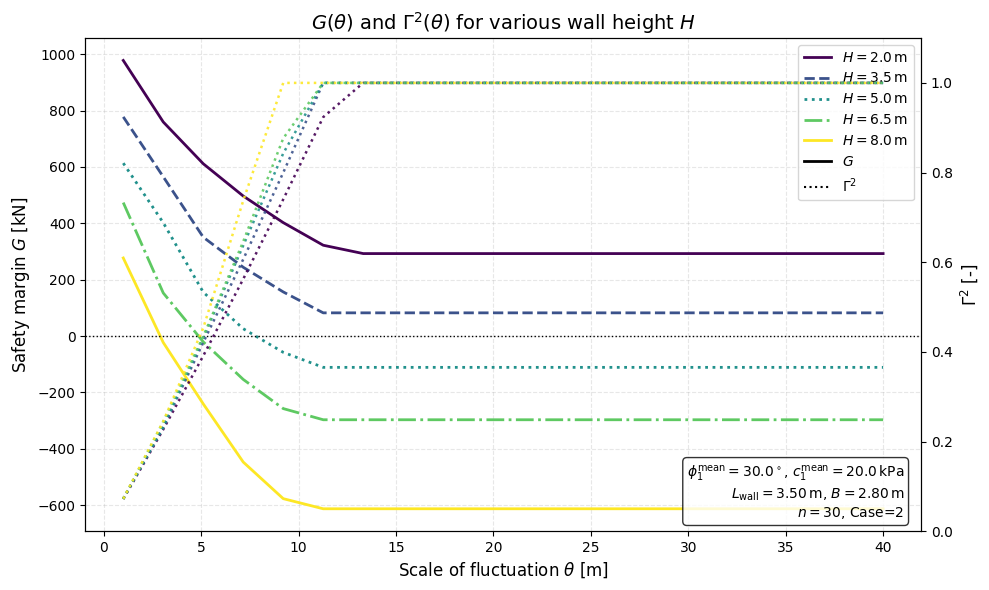

In [77]:
import itertools
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================================
# PLOTTING: G vs. θ (left axis) + Γ² (right axis) for various H
# ==========================================================
theta_values = np.linspace(1, 40, 20)   # adjust range as needed
H_values = [2, 3.5, 5, 6.5, 8]                 # different wall heights [m]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

cmap = plt.cm.viridis
colors = [cmap(i / (len(H_values) - 1)) for i in range(len(H_values))]
ls_cycle = itertools.cycle(["-", "--", ":", "-."])

for color, H_cur in zip(colors, H_values):
    ls = next(ls_cycle)
    G_vals, Gam2_vals = [], []

    for theta_cur in theta_values:

        sol_1 = solve_gamma_phi_fixed_point_wall_earth_pressure(
            L_wall=L_wall, B=B, H=H_cur, beta=beta, gamma_wall=gamma_wall, gamma1=gamma1,
            phi1_mean=phi1_mean, phi1_cov=phi1_cov, phi1_theta=theta_cur,
            c1_mean=c1_mean, c1_cov=c1_cov, c1_theta=theta_cur,
            Case=Case, n=n
        )

        N_k = sol_1['N_k']
        L_prime = sol_1['L_prime']
        tan_delta_action = sol_1['tan_delta_action']
        delta_action_deg = sol_1['delta_action_deg']

        sol_2 = solve_gamma_phi_fixed_point_wall_bearing_capacity(
            N_k = N_k , L_prime = L_prime, 
            tan_delta_action = tan_delta_action,
            delta_action_deg = delta_action_deg,
            gamma_Rv = gamma_Rv, gamma_N = gamma_N, m = m,
            gamma2 = gamma2,
            phi2_mean=phi2_mean, phi2_cov=phi2_cov, phi2_theta=theta_cur,
            c2_mean=c2_mean, c2_cov=c2_cov, c2_theta=theta_cur,
            alpha_4017=alpha_4017, beta_4017=beta_4017, Case=Case, n=n
        )
        
        G_vals.append(sol_2["G"])
        Gam2_vals.append(max(sol_2["gamma_sq"], 0.0))

    ax1.plot(theta_values, G_vals, color=color, ls=ls, lw=2,
             label=rf"$H={H_cur:.1f}\,\mathrm{{m}}$")
    ax2.plot(theta_values, Gam2_vals, color=color, ls=":", lw=1.8, alpha=0.9,
             label="_nolegend_")

ax1.axhline(0, color="k", ls=":", lw=1)
ax1.set_xlabel(r"Scale of fluctuation $\theta$ [m]", fontsize=12)
ax1.set_ylabel(r"Safety margin $G$ [kN]", fontsize=12)
ax2.set_ylabel(r"$\Gamma^2$ [-]", fontsize=12)
ax2.set_ylim(0.0, 1.1)
ax1.grid(True, ls="--", alpha=0.3)

# legends
handles, labels = ax1.get_legend_handles_labels()
style_handles = [
    Line2D([0], [0], color="k", lw=2, ls="-", label=r"$G$"),
    Line2D([0], [0], color="k", lw=1.5, ls=":", label=r"$\Gamma^2$")
]
ax1.legend(handles + style_handles, labels + [r"$G$", r"$\Gamma^2$"], loc="best")

param_text = (
    rf"$\phi_1^\mathrm{{mean}}={phi1_mean:.1f}^\circ$, "
    rf"$c_1^\mathrm{{mean}}={c1_mean:.1f}\,$kPa" + "\n" +
    rf"$L_\mathrm{{wall}}={L_wall:.2f}\,$m, $B={B:.2f}\,$m" + "\n" +
    rf"$n={n}$, Case={Case}"
)
ax1.text(0.98, 0.02, param_text, transform=ax1.transAxes,
         ha="right", va="bottom", fontsize=10,
         bbox=dict(facecolor="white", alpha=0.8, boxstyle="round"))

ax1.set_title(r"$G(\theta)$ and $\Gamma^2(\theta)$ for various wall height $H$", fontsize=14)

fig.tight_layout()
plt.show()


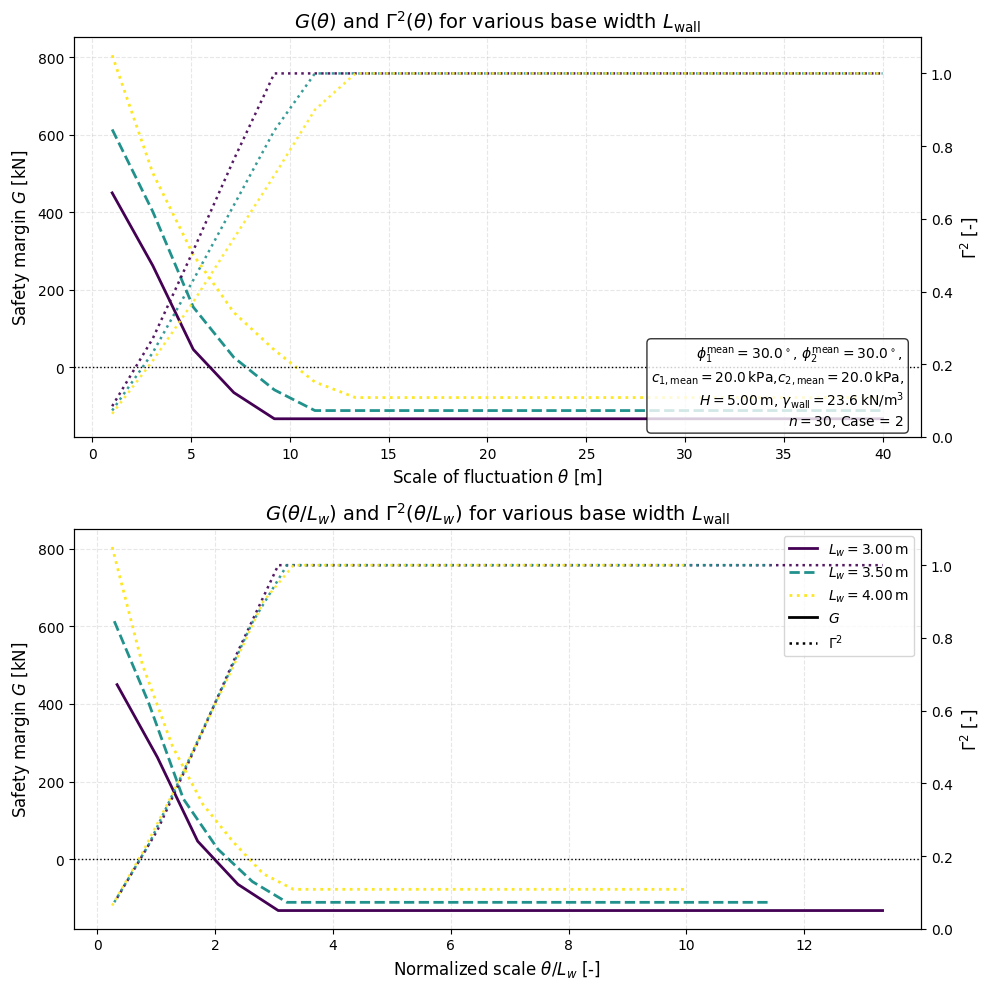

In [78]:
import itertools
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================================
# RETAINING WALL — G(θ) and Γ²(θ) plots for various L_wall
# ==========================================================
theta_values = np.linspace(1, 40, 20)
L_wall_values = [3.0, 3.5, 4.0]   # [m]
H_fixed = 5.0                     # fixed wall height

curves = []
for Lw in L_wall_values:
    B_cur = Lw / 1.25
    G_vals, Gam2_vals = [], []
    for theta_cur in theta_values:
        
        sol_1 = solve_gamma_phi_fixed_point_wall_earth_pressure(
            L_wall=Lw, B=B_cur, H=H_fixed, beta=beta, gamma_wall=gamma_wall, gamma1=gamma1,
            phi1_mean=phi1_mean, phi1_cov=phi1_cov, phi1_theta=theta_cur,
            c1_mean=c1_mean, c1_cov=c1_cov, c1_theta=theta_cur,
            Case=Case, n=n
        )

        N_k = sol_1['N_k']
        L_prime = sol_1['L_prime']
        tan_delta_action = sol_1['tan_delta_action']
        delta_action_deg = sol_1['delta_action_deg']

        sol_2 = solve_gamma_phi_fixed_point_wall_bearing_capacity(
            N_k = N_k , L_prime = L_prime, 
            tan_delta_action = tan_delta_action,
            delta_action_deg = delta_action_deg,
            gamma_Rv = gamma_Rv, gamma_N = gamma_N, m = m,
            gamma2 = gamma2,
            phi2_mean=phi2_mean, phi2_cov=phi2_cov, phi2_theta=theta_cur,
            c2_mean=c2_mean, c2_cov=c2_cov, c2_theta=theta_cur,
            alpha_4017=alpha_4017, beta_4017=beta_4017, Case=Case, n=n
        )

        G_vals.append(sol_2["G"])
        Gam2_vals.append(max(sol_2["gamma_sq"], 0.0))
    curves.append({
        "Lw": Lw,
        "theta": np.array(theta_values),
        "theta_over_L": np.array(theta_values) / Lw,
        "G": np.array(G_vals),
        "Gam2": np.array(Gam2_vals)
    })

# ==========================================================
# COLOR MAP SETUP
# ==========================================================
cmap = plt.cm.viridis
colors = [cmap(i / (len(L_wall_values) - 1)) for i in range(len(L_wall_values))]
ls_cycle = itertools.cycle(["-", "--", ":", "-."])

# ==========================================================
# CREATE 2×1 PLOTS: (1) G(θ), (2) G(θ/L_wall)
# ==========================================================
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 10), sharey=False)

# ---------------------- TOP: raw θ ----------------------
ax_top2 = ax_top.twinx()
for color, c in zip(colors, curves):
    ls = next(ls_cycle)
    ax_top.plot(c["theta"], c["G"], color=color, ls=ls, lw=2,
                label=rf"$L_w={c['Lw']:.2f}\,\mathrm{{m}}$")
    ax_top2.plot(c["theta"], c["Gam2"], color=color, ls=":", lw=1.8, alpha=0.9)
ax_top.axhline(0, color="k", ls=":", lw=1)
ax_top.set_xlabel(r"Scale of fluctuation $\theta$ [m]", fontsize=12)
ax_top.set_ylabel(r"Safety margin $G$ [kN]", fontsize=12)
ax_top2.set_ylabel(r"$\Gamma^2$ [-]", fontsize=12)
ax_top2.set_ylim(0.0, 1.1)
ax_top.grid(True, ls="--", alpha=0.3)
ax_top.set_title(r"$G(\theta)$ and $\Gamma^2(\theta)$ for various base width $L_\mathrm{wall}$", fontsize=14)

# ---------------------- BOTTOM: normalized θ/L ----------------------
ax_bot2 = ax_bot.twinx()
ls_cycle = itertools.cycle(["-", "--", ":", "-."])
for color, c in zip(colors, curves):
    ls = next(ls_cycle)
    ax_bot.plot(c["theta_over_L"], c["G"], color=color, ls=ls, lw=2,
                label=rf"$L_w={c['Lw']:.2f}\,\mathrm{{m}}$")
    ax_bot2.plot(c["theta_over_L"], c["Gam2"], color=color, ls=":", lw=1.8, alpha=0.9)
ax_bot.axhline(0, color="k", ls=":", lw=1)
ax_bot.set_xlabel(r"Normalized scale $\theta/L_w$ [-]", fontsize=12)
ax_bot.set_ylabel(r"Safety margin $G$ [kN]", fontsize=12)
ax_bot2.set_ylabel(r"$\Gamma^2$ [-]", fontsize=12)
ax_bot2.set_ylim(0.0, 1.1)
ax_bot.grid(True, ls="--", alpha=0.3)
ax_bot.set_title(r"$G(\theta/L_w)$ and $\Gamma^2(\theta/L_w)$ for various base width $L_\mathrm{wall}$", fontsize=14)

# ==========================================================
# LEGEND + PARAMETER BOX
# ==========================================================
# --- Combined legend for G and Gamma² ---
style_handles = [
    Line2D([0], [0], color="k", ls="-", lw=2, label=r"$G$"),
    Line2D([0], [0], color="k", ls=":", lw=1.8, label=r"$\Gamma^2$")
]
hD, lD = ax_bot.get_legend_handles_labels()
ax_bot.legend(hD + style_handles, lD + [r"$G$", r"$\Gamma^2$"], loc="best")

# --- Parameter text box (same as strip foundation style) ---
param_text = (
    rf"$\phi_1^\mathrm{{mean}} = {phi1_mean:.1f}^\circ$, "+
    rf"$\phi_2^\mathrm{{mean}} = {phi2_mean:.1f}^\circ$, "+ "\n"+
    rf"$c_{{1,\mathrm{{mean}}}} = {c1_mean:.1f}\,\mathrm{{kPa}}$,"+
    rf"$c_{{2,\mathrm{{mean}}}} = {c2_mean:.1f}\,\mathrm{{kPa}}$,"+ "\n"+
    rf"$H = {H_fixed:.2f}\,\mathrm{{m}}$, "+
    rf"$\gamma_\mathrm{{wall}} = {gamma_wall:.1f}\,\mathrm{{kN/m^3}}$" + "\n" +
    rf"$n = {n}$, Case = {Case}"
)
ax_top.text(
    0.98, 0.02, param_text, transform=ax_top.transAxes,
    ha="right", va="bottom", fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8, boxstyle="round")
)

fig.tight_layout()
plt.show()


this is to have the normalised graph for H, but not much use

In [79]:
# import itertools
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# # ==========================================================
# # PLOTTING: G vs. θ and G vs. θ/H for various H
# # ==========================================================
# theta_values = np.linspace(1, 40, 20)
# H_values = [2, 3.5, 5, 6.5, 8]   # different wall heights

# curves = []
# for H_cur in H_values:
#     G_vals, Gam2_vals = [], []

#     for theta_cur in theta_values:

#         sol_1 = solve_gamma_phi_fixed_point_wall_earth_pressure(
#             L_wall=L_wall, B=B, H=H_cur, beta=beta, gamma_wall=gamma_wall, gamma1=gamma1,
#             phi1_mean=phi1_mean, phi1_cov=phi1_cov, phi1_theta=theta_cur,
#             c1_mean=c1_mean, c1_cov=c1_cov, c1_theta=theta_cur,
#             Case=Case, n=n
#         )

#         N_k = sol_1['N_k']
#         L_prime = sol_1['L_prime']
#         tan_delta_action = sol_1['tan_delta_action']
#         delta_action_deg = sol_1['delta_action_deg']

#         sol_2 = solve_gamma_phi_fixed_point_wall_bearing_capacity(
#             N_k=N_k, L_prime=L_prime,
#             tan_delta_action=tan_delta_action,
#             delta_action_deg=delta_action_deg,
#             gamma_Rv=gamma_Rv, gamma_N=gamma_N, m=m,
#             gamma2=gamma2,
#             phi2_mean=phi2_mean, phi2_cov=phi2_cov, phi2_theta=theta_cur,
#             c2_mean=c2_mean, c2_cov=c2_cov, c2_theta=theta_cur,
#             alpha_4017=alpha_4017, beta_4017=beta_4017, Case=Case, n=n
#         )

#         G_vals.append(sol_2["G"])
#         Gam2_vals.append(max(sol_2["gamma_sq"], 0.0))

#     curves.append({
#         "H": H_cur,
#         "theta": theta_values,
#         "theta_over_H": theta_values / H_cur,
#         "G": np.array(G_vals),
#         "Gam2": np.array(Gam2_vals)
#     })

# # ==========================================================
# # COLOR MAP
# # ==========================================================
# cmap = plt.cm.viridis
# colors = [cmap(i / (len(H_values) - 1)) for i in range(len(H_values))]
# ls_cycle = itertools.cycle(["-", "--", ":", "-."])

# # ==========================================================
# # CREATE 2×1 SUBPLOTS
# # ==========================================================
# fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 10), sharey=False)

# # ==========================================================
# # TOP PLOT: raw θ
# # ==========================================================
# ax_top2 = ax_top.twinx()
# ls_cycle = itertools.cycle(["-", "--", ":", "-."])

# for color, c in zip(colors, curves):
#     ls = next(ls_cycle)
#     ax_top.plot(c["theta"], c["G"], color=color, ls=ls, lw=2,
#                 label=rf"$H={c['H']:.1f}\,\mathrm{{m}}$")
#     ax_top2.plot(c["theta"], c["Gam2"], color=color, ls=":", lw=1.8, alpha=0.9)

# ax_top.axhline(0, color="k", ls=":", lw=1)
# ax_top.set_xlabel(r"Scale of fluctuation $\theta$ [m]")
# ax_top.set_ylabel(r"Safety margin $G$ [kN]")
# ax_top2.set_ylabel(r"$\Gamma^2$ [-]")
# ax_top2.set_ylim(0, 1.1)
# ax_top.grid(True, ls="--", alpha=0.3)
# ax_top.set_title(r"$G(\theta)$ and $\Gamma^2(\theta)$ for various wall heights $H$")

# # ==========================================================
# # BOTTOM PLOT: normalized θ/H
# # ==========================================================
# ax_bot2 = ax_bot.twinx()
# ls_cycle = itertools.cycle(["-", "--", ":", "-."])

# for color, c in zip(colors, curves):
#     ls = next(ls_cycle)
#     ax_bot.plot(c["theta_over_H"], c["G"], color=color, ls=ls, lw=2,
#                 label=rf"$H={c['H']:.1f}\,\mathrm{{m}}$")
#     ax_bot2.plot(c["theta_over_H"], c["Gam2"], color=color, ls=":", lw=1.8, alpha=0.9)

# ax_bot.axhline(0, color="k", ls=":", lw=1)
# ax_bot.set_xlabel(r"Normalized scale $\theta/H$ [-]")
# ax_bot.set_ylabel(r"Safety margin $G$ [kN]")
# ax_bot2.set_ylabel(r"$\Gamma^2$ [-]")
# ax_bot2.set_ylim(0, 1.1)
# ax_bot.grid(True, ls="--", alpha=0.3)
# ax_bot.set_title(r"$G(\theta/H)$ and $\Gamma^2(\theta/H)$ for various wall heights $H$")

# # ==========================================================
# # LEGEND + PARAMETER BOX
# # ==========================================================
# handles, labels = ax_bot.get_legend_handles_labels()
# style_handles = [
#     Line2D([0], [0], color="k", lw=2, ls="-", label=r"$G$"),
#     Line2D([0], [0], color="k", lw=1.5, ls=":", label=r"$\Gamma^2$")
# ]
# ax_bot.legend(handles + style_handles, labels + [r"$G$", r"$\Gamma^2$"], loc="best")

# param_text = (
#     rf"$\phi_1^\mathrm{{mean}}={phi1_mean:.1f}^\circ$, "
#     rf"$c_1^\mathrm{{mean}}={c1_mean:.1f}\,$kPa" + "\n"
#     rf"$L_\mathrm{{wall}}={L_wall:.2f}\,$m, $B={B:.2f}\,$m" + "\n"
#     rf"$n={n}$, Case={Case}"
# )

# ax_top.text(
#     0.98, 0.02, param_text, transform=ax_top.transAxes,
#     ha="right", va="bottom", fontsize=10,
#     bbox=dict(facecolor="white", alpha=0.8, boxstyle="round")
# )

# fig.tight_layout()
# plt.show()


To plot 2D effect to investigate friction angle and cohesion individually (outdated)

In [80]:
# # ----------------------------------------------------------
# #  To plot 2D effect to investigate friction angle and cohesion individually
# # ----------------------------------------------------------

# theta_range = np.linspace(0.3,30, 300)  # Scale of fluctuation range, 0.3 to 7

# # Define parameter ranges
# theta_phi_grid, theta_c_grid = np.meshgrid(theta_range, theta_range)

# # Calculate G values for all combinations
# G_values = np.zeros_like(theta_phi_grid)
# for i in range(len(theta_range)):
#     for j in range(len(theta_range)):
        
#         theta_phi=theta_phi_grid[i,j]
#         theta_c=theta_c_grid[i,j]

#         phi1_k = characteristic_value (phi1_mean, phi1_cov_0, theta_phi, l_sum, Case, n_0)
#         phi2_k = characteristic_value (phi2_mean, phi2_cov_0, theta_phi, l_sum, Case, n_0)
#         c_k = characteristic_value (c_mean, c_cov_0, theta_c, l_sum, Case, n_0)

#         G_values[i,j]  = delta_action_and_G (B_0, L_wall_0, H_0, beta, gamma_wall, gamma1, gamma2, phi1_k, phi2_k, c_k) [1]

# print (G_values)

# # Create the plot
# plt.figure(figsize=(10, 8))

# # --- threshold Fix: Symmetric Normalization Around Zero ---
# G_max = np.max(np.abs(G_values))  # Largest magnitude (positive or negative)
# vmin, vmax = -G_max, G_max  # Ensures zero is centered in the colormap

# # Create custom colormap: red (unsafe) -> white (G=0) -> green (safe)
# colors = [
#     (0.5, 0.0, 0.0),  # Deep red
#     (1.0, 0.7, 0.7),  # Light red (near zero)
#     (1, 1, 1),        # Pure white at zero
#     (0.7, 1.0, 0.7),  # Light green (near zero)
#     (0.0, 0.5, 0.0)   # Deep green
# ]
# cmap_custom = LinearSegmentedColormap.from_list('danger_safe', colors, N=512)


# # Create contour plot
# contour = plt.contourf(theta_phi_grid, theta_c_grid, G_values, levels=20, cmap=cmap_custom, alpha=0.8, vmin=vmin, vmax=vmax)
# plt.colorbar(contour, label='Limit state function G')

# # Add contour lines
# CS = plt.contour(theta_phi_grid, theta_c_grid, G_values, 
#                 levels=[-5, 0, 5, 10, 15, 20], colors='black', linewidths=0.5)
# plt.clabel(CS, inline=True, fontsize=10)

# # Highlight the threshold point (minimum G)
# min_idx = np.unravel_index(np.argmin(G_values), G_values.shape)
# plt.scatter(theta_phi_grid[min_idx], theta_c_grid[min_idx], 
#            color='black', marker='x', s=100, label=f'threshold point (G={G_values[min_idx]:.1f})')

# # Formatting
# plt.xlabel(r'Scale of fluctuation for friction angle $\theta_\phi$ [m]', fontsize=12)
# plt.ylabel(r'Scale of fluctuation for cohesion $\theta_c$ [m]', fontsize=12)
# plt.title('Limit state function G vs. scales of fluctuation - Ground Failure', fontsize=14)
# plt.grid(True, linestyle='--', alpha=0.3)
# plt.legend()

# # Add text annotation about safety
# plt.text(0.5, 0.95, 'G > 0 = Safe', transform=plt.gca().transAxes,
#         ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

# #Add parameter list as text box (upper right corner)
# param_text = (
#     rf"Parameters:" + "\n"
#     rf"$n = {n_0}$" + "\n"
#     rf"$L_{{\mathrm{{wall}}}} = {L_wall_0}\, \mathrm{{m}}$" + "\n"
#     rf"$H = {H_0}\, \mathrm{{m}},\ \beta = {beta}^\circ$" + "\n"
#     rf"$\gamma_{{\mathrm{{wall}}}} = {gamma_wall}\, \mathrm{{kN/m^3}}$" + "\n"
#     rf"$\gamma_1 = {gamma1}\, \mathrm{{kN/m^3}}$" + "\n"
#     rf"$\gamma_2 = {gamma2}\, \mathrm{{kN/m^3}}$" + "\n"
#     rf"$\phi_{{1,\mathrm{{mean}}}} = {phi1_mean}^\circ$, $\mathrm{{COV}} = {phi1_cov_0}$" + "\n"
#     rf"$\phi_{{2,\mathrm{{mean}}}} = {phi2_mean}^\circ$, $\mathrm{{COV}} = {phi2_cov_0}$" + "\n"
#     rf"$c_{{\mathrm{{mean}}}} = {c_mean}\, \mathrm{{kPa}}$, $\mathrm{{COV}} = {c_cov_0}$" + "\n"
#     rf"Case {Case}"
# )

# plt.text(0.98, 0.9, param_text, transform=plt.gca().transAxes,
#          ha='right', va='top', fontsize=12,
#          bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

# plt.tight_layout()

# plt.show()

In [81]:
# # ----------------------------------------------------------
# #  To plot 2D effect to investigate friction angle and cohesion individually (normalised)
# # ----------------------------------------------------------

# L_infl = l_sum  

# # Create normalized grids (theta/L)
# theta_phi_normalized = theta_phi_grid / L_infl
# theta_c_normalized = theta_c_grid / L_infl

# # Create the plot
# plt.figure(figsize=(10, 8))

# # --- threshold Fix: Symmetric Normalization Around Zero ---
# G_max = np.max(np.abs(G_values))  # Largest magnitude (positive or negative)
# vmin, vmax = -G_max, G_max  # Ensures zero is centered in the colormap

# # Create custom colormap: red (unsafe) -> white (G=0) -> green (safe)
# colors = [
#     (0.5, 0.0, 0.0),  # Deep red
#     (1.0, 0.7, 0.7),  # Light red (near zero)
#     (1, 1, 1),        # Pure white at zero
#     (0.7, 1.0, 0.7),  # Light green (near zero)
#     (0.0, 0.5, 0.0)   # Deep green
# ]
# cmap_custom = LinearSegmentedColormap.from_list('danger_safe', colors, N=512)


# # Create contour plot
# contour = plt.contourf(theta_phi_normalized, theta_c_normalized, G_values, levels=20, cmap=cmap_custom, alpha=0.8, vmin=vmin, vmax=vmax)
# plt.colorbar(contour, label='Limit state function G')

# # Add contour lines
# CS = plt.contour(theta_phi_normalized, theta_c_normalized, G_values, 
#                 levels=[-5, 0, 5, 10, 15, 20], colors='black', linewidths=0.5)
# plt.clabel(CS, inline=True, fontsize=10)

# # Highlight the threshold point (minimum G)
# min_idx = np.unravel_index(np.argmin(G_values), G_values.shape)
# x_coord = theta_phi_normalized[min_idx]
# y_coord = theta_c_normalized[min_idx]

# # Add text label with coordinate values near the marker
# plt.text(x_coord + 0.01, y_coord, f'({x_coord:.1f}, {y_coord:.1f})', 
#          color='black', fontsize=10, va='center')


# plt.scatter(theta_phi_normalized[min_idx], theta_c_normalized[min_idx], 
#            color='black', marker='x', s=100, label=f'threshold point (G={G_values[min_idx]:.1f})')

# # Formatting
# plt.xlabel(r'Normalized scale of fluctuation for friction angle $\theta_\phi/L$', fontsize=12)
# plt.ylabel(r'Normalized scale of fluctuation for cohesion $\theta_c/L$', fontsize=12)
# plt.title('Limit state function G vs. normalised scales of fluctuation - Ground Failure', fontsize=14)
# plt.grid(True, linestyle='--', alpha=0.3)
# plt.legend()

# # Add text annotation about safety
# plt.text(0.5, 0.95, 'G > 0 = Safe', transform=plt.gca().transAxes,
#         ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

# #Add parameter list as text box (upper right corner)
# param_text = (
#     rf"Parameters:" + "\n"
#     rf"$n = {n_0}$" + "\n"
#     rf"$L_{{\mathrm{{wall}}}} = {L_wall_0}\, \mathrm{{m}}$" + "\n"
#     rf"$H = {H_0}\, \mathrm{{m}},\ \beta = {beta}^\circ$" + "\n"
#     rf"$\gamma_{{\mathrm{{wall}}}} = {gamma_wall}\, \mathrm{{kN/m^3}}$" + "\n"
#     rf"$\gamma_1 = {gamma1}\, \mathrm{{kN/m^3}}$" + "\n"
#     rf"$\gamma_2 = {gamma2}\, \mathrm{{kN/m^3}}$" + "\n"
#     rf"$\phi_{{1,\mathrm{{mean}}}} = {phi1_mean}^\circ$, $\mathrm{{COV}} = {phi1_cov_0}$" + "\n"
#     rf"$\phi_{{2,\mathrm{{mean}}}} = {phi2_mean}^\circ$, $\mathrm{{COV}} = {phi2_cov_0}$" + "\n"
#     rf"$c_{{\mathrm{{mean}}}} = {c_mean}\, \mathrm{{kPa}}$, $\mathrm{{COV}} = {c_cov_0}$" + "\n"
#     rf"Case {Case}"
# )

# plt.text(0.98, 0.9, param_text, transform=plt.gca().transAxes,
#          ha='right', va='top', fontsize=12,
#          bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

# plt.tight_layout()

# plt.show()

SA (outdated)

In [82]:
# # ----------------------------------------------------------
# # SA
# # ----------------------------------------------------------

# from SALib.sample import sobol as sobol_sample
# from SALib.analyze import sobol
# import matplotlib.pyplot as plt

# problem = {
#     "num_vars": 12,
#     "names": [
#         "phi1_cov",
#         "phi2_cov",
#         "n",
#         "c_cov",
#         "theta_phi", 
#         "theta_c",
#         "L_wall",
#         "H", 
#         "beta",
#         "gamma_wall_SA",
#         "gamma1_SA",
#         "gamma2_SA"
#     ],
#     "bounds": [
#         [0.05, 0.15], # EC-7
#         [0.05, 0.15], # EC-7
#         [10, 30],
#         [0.3, 0.5], # EC-7
#         [1, 7],
#         [1, 7], 
#         [3,6],
#         [4,7],
#         [0,10],
#         [20,25],
#         [16,21],
#         [16,21]
#     ]
# }

# # --- Generate Sobol samples ---
# N = 512  # base sample size
# param_values = sobol_sample.sample(problem, N, calc_second_order=True)

# # --- Evaluate the model for each sample ---
# def evaluate_model(X):
#     outputs = []
#     for row in X:
#         phi1_cov_SA, phi2_cov_SA, n_SA, c_cov_SA, theta_phi_SA, theta_c_SA, L_wall_SA, H_SA, beta_SA, gamma_wall_SA, gamma1_SA, gamma2_SA = row
#         n_SA = int(round(n_SA))
#         B_SA = L_wall_SA / 1.25

#         delta_SA = delta_action_and_G (B_SA, L_wall_SA, H_SA, beta_SA, gamma_wall_SA, gamma1_SA, gamma2_SA, phi1_mean, phi2_mean, c_mean)[0] # we assume the true delta
#         l_sum_SA = characteristic_length (alpha_4017, beta_4017, phi2_mean, delta_SA, L_wall_SA) # we assume the true l

#         phi1_k = characteristic_value (phi1_mean, phi1_cov_SA, theta_phi_SA, l_sum_SA, Case, n_SA)
#         phi2_k = characteristic_value (phi2_mean, phi2_cov_SA, theta_phi_SA, l_sum_SA, Case, n_SA)
#         c_k = characteristic_value (c_mean, c_cov_SA, theta_c_SA, l_sum_SA, Case, n_SA)

#         # phi1_d = degrees(atan(tan(radians(phi1_k)) / gamma_phi))
#         # phi2_d = degrees(atan(tan(radians(phi2_k)) / gamma_phi))
#         # c_d = c_k / gamma_c

#         G = delta_action_and_G (B_SA, L_wall_SA, H_SA, beta_SA, gamma_wall_SA, gamma1_SA, gamma2_SA, phi1_k, phi2_k, c_k) [1]
        
#         outputs.append(G)

#     return np.array(outputs)

# Y = evaluate_model(param_values)
# Y = np.nan_to_num(Y, nan=np.max(Y[np.isfinite(Y)]) )  # Replace nan with large value

# # --- Sobol analysis ---
# Si = sobol.analyze(problem, Y, calc_second_order=True, print_to_console=True)

# # --- Plot S1 ---
# fig1, ax1 = plt.subplots(figsize=(10, 10))
# x_labels = problem["names"]
# x = np.arange(len(x_labels))

# ax1.bar(x, Si["S1"], width=0.4, label="First-order (S1)", color='skyblue')
# ax1.set_ylabel("Sobol Sensitivity Index")
# ax1.set_xticks(x)
# ax1.set_xticklabels(x_labels, rotation=45)
# ax1.set_title("First-order Sobol Sensitivity Indices (S1)")
# ax1.grid(True)
# plt.tight_layout()
# plt.show()

# # --- Plot ST ---
# fig2, ax2 = plt.subplots(figsize=(10, 10))
# ax2.bar(x, Si["ST"], width=0.4, label="Total-order (ST)", color='salmon')
# ax2.set_ylabel("Sobol Sensitivity Index")
# ax2.set_xticks(x)
# ax2.set_xticklabels(x_labels, rotation=45)
# ax2.set_title("Total-order Sobol Sensitivity Indices (ST)")
# ax2.grid(True)
# plt.tight_layout()
# plt.show()


In [83]:
# # ----------------------------------------------------------
# # SA S2
# # ----------------------------------------------------------

# from matplotlib import cm
# import numpy as np

# # --- Plot S2 (Interaction Effects) ---
# fig3, ax3 = plt.subplots(figsize=(10, 8))

# # Get the S2 matrix
# S2_matrix = Si['S2']

# # Create a mask for the upper triangle (since the matrix is symmetric)
# mask = np.triu(np.ones_like(S2_matrix, dtype=bool))

# # Create a heatmap of the S2 values
# im = ax3.imshow(S2_matrix, cmap=cm.viridis, vmin=0, vmax =0.1 ) # vmax=np.nanmax(S2_matrix)

# # Add colorbar
# cbar = fig3.colorbar(im, ax=ax3)
# cbar.set_label('Second-order Sobol Index')

# # Set ticks and labels
# ax3.set_xticks(np.arange(len(problem['names'])))
# ax3.set_yticks(np.arange(len(problem['names'])))
# ax3.set_xticklabels(problem['names'], rotation=45)
# ax3.set_yticklabels(problem['names'])

# # Add values to each cell
# for i in range(len(problem['names'])):
#     for j in range(len(problem['names'])):
#         if not mask[i,j]:  # Only show lower triangle
#             if not np.isnan(S2_matrix[i,j]):
#                 text = ax3.text(j, i, f"{S2_matrix[i,j]:.2f}",
#                               ha="center", va="center", color="w")

# ax3.set_title("Second-order Sobol Indices (Interaction Effects)")
# plt.tight_layout()
# plt.show()

Slider (outdated)

In [84]:
# # ----------------------------------------------------------
# # slider
# # ----------------------------------------------------------

# import matplotlib.pyplot as plt
# import ipywidgets as widgets
# from IPython.display import display

# # Define parameter ranges
# theta_vals = theta_range
# cov_vals = np.linspace(0.05, 0.5, 20)
# H_vals = np.linspace(1, 10, 19) #10
# L_vals = np.linspace(2, 5.5, 14) #9
# B_vals = L_vals / 1.25 # we fix the ratio for a easier setting

# def plot_G(vary='phi1_theta', H=4, 
#            L_wall=3.5,
#            phi1_cov=0.25, phi1_theta=5,
#            phi2_cov=0.25, phi2_theta=5,
#            c_cov=0.25, c_theta=5):
    
#     if vary == 'phi1_theta':
#         x_vals = theta_vals
#         x_label = r'$\theta_{\phi_1}$ (m)'
#     elif vary == 'phi2_theta':
#         x_vals = theta_vals
#         x_label = r'$\theta_{\phi_2}$ (m)'
#     elif vary == 'c_theta':
#         x_vals = theta_vals
#         x_label = r'$\theta_{c}$ (m)'
#     elif vary == 'phi1_cov':
#         x_vals = cov_vals
#         x_label = r'CoV$_{\phi_1}$'
#     elif vary == 'phi2_cov':
#         x_vals = cov_vals
#         x_label = r'CoV$_{\phi_2}$'
#     elif vary == 'c_cov':
#         x_vals = cov_vals
#         x_label = r'CoV$_{c}$'
#     elif vary == 'H':
#         x_vals = H_vals
#         x_label = r'$H$ (m)'
#     elif vary == 'B':
#         x_vals = B_vals
#         x_label = r'$B$ (m)'
#     elif vary == 'L_wall':
#         x_vals = L_vals
#         x_label = r'$L_{\text{wall}}$ (m)'
#     else:
#         return
    
#     G_vals = []
#     for x in x_vals:
#         # Vary one parameter at a time
#         H_x = x if vary == 'H' else H
#         # B_x = x if vary == 'B' else B
#         L_x = x if vary == 'L_wall' else L_wall
#         phi1_cov_x = x if vary == 'phi1_cov' else phi1_cov
#         phi2_cov_x = x if vary == 'phi2_cov' else phi2_cov
#         c_cov_x = x if vary == 'c_cov' else c_cov
#         phi1_theta_x = x if vary == 'phi1_theta' else phi1_theta
#         phi2_theta_x = x if vary == 'phi2_theta' else phi2_theta
#         c_theta_x = x if vary == 'c_theta' else c_theta

#         try:
#             # Calculate delta, characteristic length as our truth
#             B_x = L_x/1.25
#             delta = delta_action_and_G(B_x, L_x, H_x, beta, gamma_wall, gamma1, gamma2, phi1_mean, phi2_mean, c_mean)[0]
#             l_sum = characteristic_length(alpha_4017, beta_4017, phi2_mean, delta, L_x)

#             # Characteristic values
#             phi1_k = characteristic_value(phi1_mean, phi1_cov_x, phi1_theta_x, l_sum, Case, n_0)
#             phi2_k = characteristic_value(phi2_mean, phi2_cov_x, phi2_theta_x, l_sum, Case, n_0)
#             c_k = characteristic_value(c_mean, c_cov_x, c_theta_x, l_sum, Case, n_0)

#             # Design values
#             # phi1_d = degrees(atan(tan(radians(phi1_k)) / gamma_phi))
#             # phi2_d = degrees(atan(tan(radians(phi2_k)) / gamma_phi))
#             # c_d = c_k / gamma_c

#             if phi1_k < beta:
#                 G_vals.append(np.nan)
#                 continue
#             else:
#             # Compute G
#                 G = delta_action_and_G(B_x, L_x, H_x, beta, gamma_wall, gamma1, gamma2, phi1_k, phi2_k, c_k)[1]
#                 G_vals.append(G)

#         except Exception as e:
#             G_vals.append(np.nan)

#     # Convert to array
#     G_vals = np.array(G_vals)
#     min_idx = np.nanargmin(G_vals)
#     x_crit = x_vals[min_idx]
#     G_crit = G_vals[min_idx]

#     # Plot
#     plt.figure(figsize=(8, 5))
#     plt.plot(x_vals, G_vals, marker='o', linestyle='-', color='darkgreen')
#     plt.plot(x_crit, G_crit, 'ro', label=f'Min G = {G_crit:.2f}\n@ {x_label} = {x_crit:.2f}')
#     plt.annotate(f'{G_crit:.2f} at {x_label} = {x_crit:.2f}',
#                  xy=(x_crit, G_crit),
#                  xytext=(x_crit + 0.05*(x_vals[-1]-x_vals[0]), G_crit + 0.05),
#                  arrowprops=dict(facecolor='red', arrowstyle='->'),
#                  fontsize=10, color='red')
    
#     plt.xlabel(x_label)
#     plt.ylabel(r'Limit State Function $G$')
#     plt.title(f'Effect of {x_label} on $G$')
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# # Create interactive UI
# interact_ui = widgets.interactive(
#     plot_G,
#     vary=widgets.Dropdown(
#         options=['phi1_theta', 'phi2_theta', 'c_theta', 'phi1_cov', 'phi2_cov', 'c_cov', 'H', 'L_wall'],
#         value='phi1_theta',
#         description='Vary:',
#     ),
#     H=widgets.FloatSlider(min=1, max=12, step=0.5, value=4, description='H (m)'),
#     #B=widgets.FloatSlider(min=1, max=6, step=0.25, value=2.5, description='B (m)'),
#     L_wall=widgets.FloatSlider(min=2, max=10, step=0.25, value=3.5, description='L_wall (m)'),
#     phi1_cov=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.2, description='CoV φ1'),
#     phi1_theta=widgets.FloatSlider(min=0.5, max=30, step=0.5, value=5, description='θ φ1'),
#     phi2_cov=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.2, description='CoV φ2'),
#     phi2_theta=widgets.FloatSlider(min=0.5, max=30, step=0.5, value=5, description='θ φ2'),
#     c_cov=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.2, description='CoV c'),
#     c_theta=widgets.FloatSlider(min=0.5, max=30, step=0.5, value=5, description='θ c'),
# )

# display(interact_ui)


Relationship between Threshold Scale of Fluctuation vs Wall Width (Outdated)

In [85]:
# # ----------------------------------------------------------
# # Threshold Scale of Fluctuation vs Wall Width in ground failure
# # ----------------------------------------------------------

# from scipy.stats import linregress

# threshold_theta = []

# for L_wall in L_vals:
#     B = L_wall / 1.25  # for simplicity, we fixed ratio
#     min_G = float('inf')
#     worst_theta = None

#     for theta in theta_vals:
#         try:
#             # Step 1: calculate delta and l_sum with means
#             delta = delta_action_and_G(B, L_wall, H_0, beta, gamma_wall, gamma1, gamma2, phi1_mean, phi2_mean, c_mean)[0]
#             l_sum = characteristic_length(alpha_4017, beta_4017, phi2_mean, delta, L_wall)

#             # Step 2: compute characteristic values
#             phi1_k = characteristic_value(phi1_mean, phi1_cov_0, theta, l_sum, Case, n_0)
#             phi2_k = characteristic_value(phi2_mean, phi2_cov_0, theta, l_sum, Case, n_0)
#             c_k = characteristic_value(c_mean, c_cov_0, theta, l_sum, Case, n_0)

#             if phi1_k < beta:
#                 continue

#             # Step 3: evaluate limit state function
#             G = delta_action_and_G(B, L_wall, H_0, beta, gamma_wall, gamma1, gamma2, phi1_k, phi2_k, c_k)[1]

#             if G < min_G:
#                 min_G = G
#                 worst_theta = theta
#         except:
#             continue

#     threshold_theta.append(worst_theta)

# L_range =  np.array(L_vals)
# theta_crit = np.array(threshold_theta)

# #Linear regression
# slope, intercept, r_value, p_value, std_err = linregress(L_range, theta_crit)

# plt.figure(figsize=(8, 5))
# plt.plot(L_range, theta_crit, 'o-', label='Threshold $\\theta$')
# plt.plot(L_range, slope * L_range + intercept, 'r--', label='Linear Fit')

# # Regression annotation
# eq_text = rf"$\theta_{{\mathrm{{threshold}}}} = {slope:.2f} \cdot L_{{\mathrm{{wall}}}}  + {intercept:.2f}$"
# plt.text(
#     0.05, 0.95, eq_text,
#     transform=plt.gca().transAxes,
#     fontsize=12,
#     verticalalignment='top',
#     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
# )

# # Parameter description
# param_text = (
#     f"Parameters:\n"
#     f"$H = {H_0}\\ \\mathrm{{m}}$\n"
#     f"$\\phi_1$: mean = {phi1_mean}° , COV = {phi1_cov_0}\n"
#     f"$\\phi_2$: mean = {phi2_mean}° , COV = {phi2_cov_0}\n"
#     f"$c$: mean = {c_mean}kPa, COV = {c_cov_0}\n"
#     f"Case {Case}, $n = {n_0}$"
# )
# plt.text(
#     0.65, 0.5, param_text,
#     transform=plt.gca().transAxes,
#     fontsize=10,
#     verticalalignment='top',
#     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
# )

# # Labels
# plt.xlabel(r'Foundation Width $L_{\mathrm{wall}}$ (m)')
# plt.ylabel(r'Threshold Scale of Fluctuation $\theta$ (m)')
# plt.title('Threshold Scale of Fluctuation vs Wall Width in ground failure')
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [86]:
# # # ----------------------------------------------------------
# # # Threshold Scale of Fluctuation vs Wall Height in Ground Failure
# # # ----------------------------------------------------------

# threshold_theta = []

# for H in H_vals:
#     B = L_wall_0 / 1.25
#     min_G = float('inf')
#     worst_theta = None

#     for theta in theta_vals:
#         try:
#             delta = delta_action_and_G(B, L_wall_0, H, beta, gamma_wall, gamma1, gamma2, phi1_mean, phi2_mean, c_mean)[0]
#             l_sum = characteristic_length(alpha_4017, beta_4017, phi2_mean, delta, L_wall_0)

#             phi1_k = characteristic_value(phi1_mean, phi1_cov_0, theta, l_sum, Case, n_0)
#             phi2_k = characteristic_value(phi2_mean, phi2_cov_0, theta, l_sum, Case, n_0)
#             c_k = characteristic_value(c_mean, c_cov_0, theta, l_sum, Case, n_0)

#             if phi1_k < beta:
#                 continue

#             G = delta_action_and_G(B, L_wall_0, H, beta, gamma_wall, gamma1, gamma2, phi1_k, phi2_k, c_k)[1]

#             if G < min_G:
#                 min_G = G
#                 worst_theta = theta
#         except:
#             continue

#     threshold_theta.append(worst_theta)

# # Run and plot
# H_range= np.array(H_vals)
# theta_crit = np.array(threshold_theta)

# # Linear regression
# slope, intercept, r_value, p_value, std_err = linregress(H_range, theta_crit)

# plt.figure(figsize=(8, 5))
# plt.plot(H_range, theta_crit, 'o-', label='Threshold $\\theta$')
# plt.plot(H_range, slope * H_range + intercept, 'r--', label='Linear Fit')

# # Regression text
# eq_text = rf"$\theta_{{\mathrm{{threshold}}}} = {slope:.2f} \cdot H + {intercept:.2f}$"

# plt.text(
#     0.5, 0.95, eq_text,
#     transform=plt.gca().transAxes,
#     fontsize=12,
#     verticalalignment='top',
#     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
# )

# param_text = (
#     f"Parameters:\n"
#     f"$L_{{\\mathrm{{wall}}}} = {L_wall_0}\\ \\mathrm{{m}}$\n"
#     f"$\\phi_1$: mean = {phi1_mean}° , COV = {phi1_cov_0}\n"
#     f"$\\phi_2$: mean = {phi2_mean}° , COV = {phi2_cov_0}\n"
#     f"$c$: mean = {c_mean}kPa, COV = {c_cov_0}\n"
#     f"Case {Case}, $n = {n_0}$"
# )

# plt.text(
#     0.65, 0.75, param_text,
#     transform=plt.gca().transAxes,
#     fontsize=10,
#     verticalalignment='top',
#     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
# )

# # Labels
# plt.xlabel(r'Wall Height $H$ (m)')
# plt.ylabel(r'Threshold Scale of Fluctuation $\theta$ (m)')
# plt.title('Threshold Scale of Fluctuation vs Wall Height in Ground Failure')
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()
